# Projet Final - Forage de données (8INF436)
**Sujet :** Prédire le score de crédit d'un client bancaire  
**Groupe :** Frantxa Cabrejos, Loup-Djabril Le Bivic, Nathan Razafindratsima  
**Dataset :** Credit Score Classification - Kaggle (100 000 observations, train.csv)  
**Problème :** Classification multi-classes : Good / Standard / Poor

---
## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob, joblib, os, warnings
warnings.filterwarnings('ignore')

# preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# réduction de dimension (Chapitre 4 du cours)
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel

# modèles de classification (Chapitre 3)
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC                          # LinearSVC : noyau linéaire, O(n) -> rapide
from sklearn.calibration import CalibratedClassifierCV    # ajoute les probabilités au LinearSVC

# métriques d'évaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# oversampling pour classes déséquilibrées (Chapitre 2)
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('imports ok')

imports ok


---
## 1. Chargement du dataset

Source : https://www.kaggle.com/datasets/parisrohan/credit-score-classification  
Télécharger `train.csv` et le placer dans le dossier `data/`.

**Attention :** Sur Kaggle il y a deux fichiers, `train.csv` et `test.csv`.  
On utilise uniquement `train.csv` car `test.csv` n'a pas la colonne `Credit_Score`.  
Notre propre jeu de test vient du split 80/20 qu'on fait nous-mêmes plus bas.

In [2]:
csv_files = glob.glob('data/train.csv') + glob.glob('../data/train.csv') + glob.glob('train.csv')
print('fichiers trouvés :', csv_files)

df_raw = pd.read_csv(csv_files[0], low_memory=False)
print(f'{df_raw.shape[0]} lignes, {df_raw.shape[1]} colonnes')

fichiers trouvés : ['data/train.csv']
100000 lignes, 28 colonnes


---
## 2. Exploration du dataset

Avant de toucher quoi que ce soit, on regarde ce qu'on a.  
Ce dataset est connu pour être très sale : valeurs corrompues, types mélangés, NaN partout.

In [3]:
df_raw.head(5)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [4]:
# types et valeurs non-nulles par colonne
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [5]:
# statistiques descriptives
df_raw.describe(include='all')

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,100000,100000,100000,84998.000000,100000.000000,...,100000,100000,100000.000000,90970,100000,100000.000000,95521,100000,98800,100000
unique,100000,12500,8,10139,1788,12501,16,18940,NaN,NaN,...,4,13178,NaN,404,3,NaN,91049,7,98792,3
top,0x1602,CUS_0xd40,January,Langep,38,#F%$D@*&8,_______,36585.12,NaN,NaN,...,Standard,1360.45,NaN,15 Years and 11 Months,Yes,NaN,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,12500,44,2833,5572,7062,16,NaN,NaN,...,36479,24,NaN,446,52326,NaN,4305,25513,9,53174
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4194.170850,17.091280,...,NaN,NaN,32.285173,NaN,NaN,1403.118217,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3183.686167,117.404834,...,NaN,NaN,5.116875,NaN,NaN,8306.041270,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303.645417,-1.000000,...,NaN,NaN,20.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1625.568229,3.000000,...,NaN,NaN,28.052567,NaN,NaN,30.306660,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3093.745000,6.000000,...,NaN,NaN,32.305784,NaN,NaN,69.249473,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5957.448333,7.000000,...,NaN,NaN,36.496663,NaN,NaN,161.224249,NaN,NaN,NaN,NaN


### 2.1 Analyse des valeurs manquantes

In [6]:
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2).sort_values(ascending=False)
print('colonnes avec valeurs manquantes :')
print(missing_pct[missing_pct > 0])

colonnes avec valeurs manquantes :
Monthly_Inhand_Salary      15.00
Type_of_Loan               11.41
Name                        9.98
Credit_History_Age          9.03
Num_of_Delayed_Payment      7.00
Amount_invested_monthly     4.48
Num_Credit_Inquiries        1.96
Monthly_Balance             1.20
dtype: float64


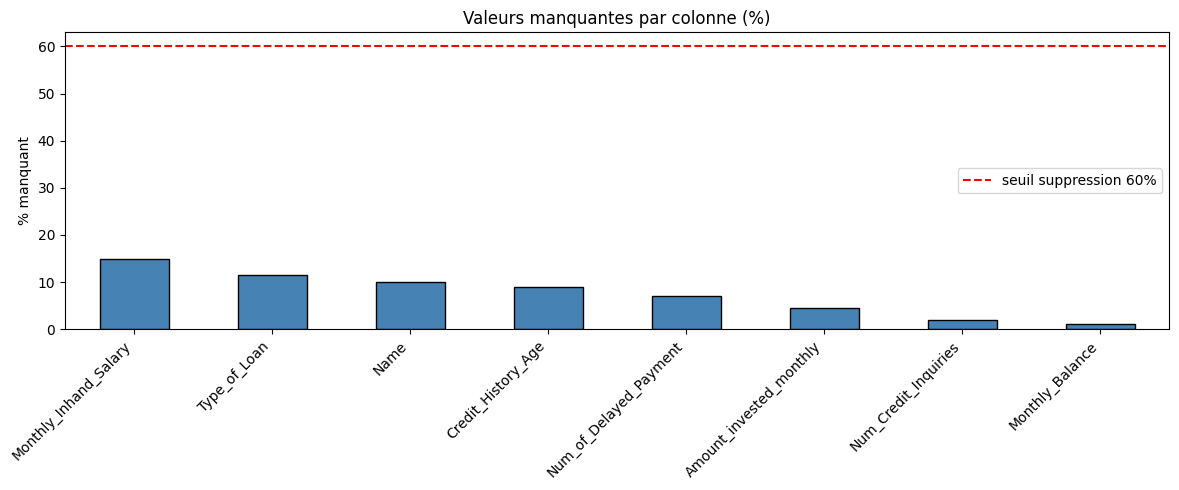

In [7]:
manquants = missing_pct[missing_pct > 0]
if len(manquants) > 0:
    plt.figure(figsize=(12, 5))
    manquants.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.axhline(60, color='red', linestyle='--', label='seuil suppression 60%')
    plt.title('Valeurs manquantes par colonne (%)')
    plt.ylabel('% manquant')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

### 2.2 Distribution de la variable cible

3 classes : Good, Standard, Poor.  
Les classes sont déséquilibrées -> on va utiliser SMOTE dans le preprocessing.

distribution variable cible :
Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


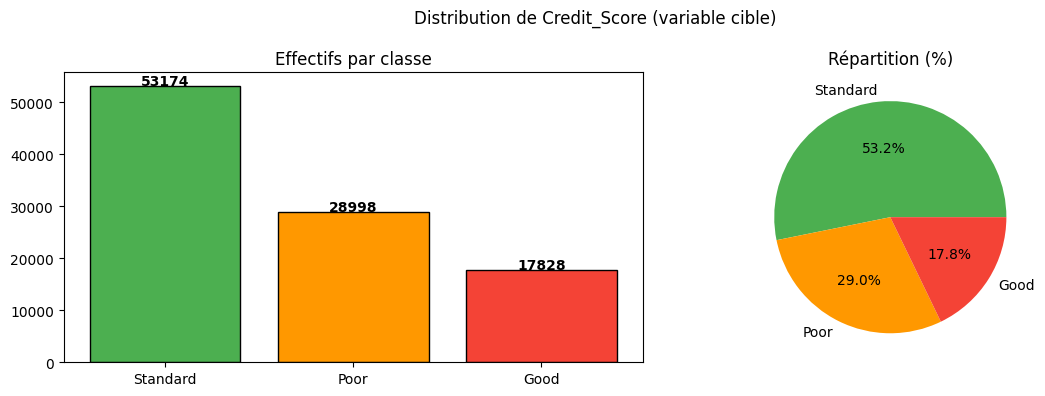

ratio déséquilibre max/min : 3.0x


In [8]:
TARGET_COL = 'Credit_Score'
print('distribution variable cible :')
print(df_raw[TARGET_COL].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df_raw[TARGET_COL].value_counts()
colors = ['#4caf50', '#ff9800', '#f44336']

bars = axes[0].bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='black')
axes[0].set_title('Effectifs par classe')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 200, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, colors=colors[:len(counts)], autopct='%1.1f%%')
axes[1].set_title('Répartition (%)')

plt.suptitle('Distribution de Credit_Score (variable cible)', fontsize=12)
plt.tight_layout()
plt.show()

ratio_dsq = counts.max() / counts.min()
print(f'ratio déséquilibre max/min : {ratio_dsq:.1f}x')

### 2.3 Exemples de données corrompues

Ce dataset est volontairement sale. Quelques exemples qu'on va devoir corriger dans le preprocessing.

In [9]:
# aperçu des valeurs dans les premières colonnes object
for col in df_raw.select_dtypes(include='object').columns[:8]:
    uniques = df_raw[col].dropna().unique()[:5]
    print(f'{col}: {uniques}')

ID: ['0x1602' '0x1603' '0x1604' '0x1605' '0x1606']
Customer_ID: ['CUS_0xd40' 'CUS_0x21b1' 'CUS_0x2dbc' 'CUS_0xb891' 'CUS_0x1cdb']
Month: ['January' 'February' 'March' 'April' 'May']
Name: ['Aaron Maashoh' 'Rick Rothackerj' 'Langep' 'Jasond' 'Deepaa']
Age: ['23' '-500' '28_' '28' '34']
SSN: ['821-00-0265' '#F%$D@*&8' '004-07-5839' '486-85-3974' '072-31-6145']
Occupation: ['Scientist' '_______' 'Teacher' 'Engineer' 'Entrepreneur']
Annual_Income: ['19114.12' '34847.84' '34847.84_' '143162.64' '30689.89']


---
## 3. Préparation des données (20 pts)

Étapes :
1. Suppression des colonnes inutiles (identifiants)
2. Nettoyage des valeurs corrompues (regex + pd.to_numeric)
3. Encodage des variables catégorielles (LabelEncoder)
4. Imputation des valeurs manquantes (médiane)
5. Normalisation min-max (Chapitre 2 du cours)
6. Split train/test 80/20 stratifié
7. Suréchantillonnage SMOTE sur le train (Chapitre 2)

In [10]:
df = df_raw.copy()

# 1. supprimer les colonnes identifiants : pas de valeur discriminante pour la classification
cols_id = ['ID', 'Customer_ID', 'Name', 'SSN', 'Month']
cols_drop = [c for c in cols_id if c in df.columns]
df.drop(columns=cols_drop, inplace=True)
print('colonnes supprimées (identifiants) :', cols_drop)
print('shape :', df.shape)

colonnes supprimées (identifiants) : ['ID', 'Customer_ID', 'Name', 'SSN', 'Month']
shape : (100000, 23)


In [11]:
# 2. nettoyage des valeurs corrompues
# les colonnes numériques sont stockées en string avec caractères parasites
# regex '[^0-9.-]' supprime tout sauf les chiffres, le point et le tiret
# pd.to_numeric avec errors='coerce' : valeurs non convertibles -> NaN

cols_num_str = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
    'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'
]

for col in cols_num_str:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('[^0-9.-]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# supprimer les valeurs aberrantes évidentes
if 'Age' in df.columns:
    df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan
if 'Annual_Income' in df.columns:
    df.loc[df['Annual_Income'] < 0, 'Annual_Income'] = np.nan

print('nettoyage numérique ok')
# print(df.dtypes)  # décommenter pour vérifier

nettoyage numérique ok


In [12]:
# séparation X / y
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f'X : {X.shape}')
print(f'colonnes numériques ({len(num_cols)}) : {num_cols}')
print(f'colonnes catégorielles ({len(cat_cols)}) : {cat_cols}')

X : (100000, 22)
colonnes numériques (17) : ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']
colonnes catégorielles (5) : ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


In [13]:
# encodage de la variable cible
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print('classes :', list(zip(le_target.classes_, range(len(le_target.classes_)))))

classes : [('Good', 0), ('Poor', 1), ('Standard', 2)]


In [14]:
# encodage des variables catégorielles avec LabelEncoder
# on remplit les NaN par 'inconnu' avant encodage pour éviter une erreur
X_enc = X.copy()
encoders = {}  # on garde les encodeurs pour les réutiliser dans l'interface

for col in cat_cols:
    X_enc[col] = X_enc[col].fillna('inconnu')
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X_enc[col].astype(str))
    encoders[col] = le

print(f'encodage ok ({len(cat_cols)} colonnes catégorielles)')

encodage ok (5 colonnes catégorielles)


In [15]:
# imputation des NaN restants par la médiane de chaque colonne
# médiane choisie car robuste aux valeurs extrêmes (ex: revenus exceptionnels)
print('NaN avant imputation :', X_enc.isnull().sum().sum())

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X_enc), columns=X_enc.columns)

print('NaN après imputation :', X_imp.isnull().sum().sum())

NaN avant imputation : 49251
NaN après imputation : 0


In [16]:
# normalisation min-max (Chapitre 2 du cours)
# formule : (x - min) / (max - min) -> toutes les valeurs entre 0 et 1
# nécessaire pour le SVM qui calcule des distances
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X_imp.columns)

print('normalisation min-max ok')
print(f'min global : {X_scaled.min().min():.3f} | max global : {X_scaled.max().max():.3f}')

normalisation min-max ok
min global : 0.000 | max global : 1.000


In [17]:
# split train/test 80/20 stratifié
# stratifié : chaque partie garde la même proportion des 3 classes
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)
print(f'train : {X_train.shape[0]} lignes | test : {X_test.shape[0]} lignes')

train : 80000 lignes | test : 20000 lignes


In [18]:
# suréchantillonnage SMOTE sur le train uniquement (Chapitre 2 du cours)
# SMOTE génère des exemples synthétiques pour les classes minoritaires
# règle absolue : jamais sur le test, qui doit rester représentatif de la réalité

vals, cnts = np.unique(y_train, return_counts=True)
ratio_dsq = cnts.max() / cnts.min()
print(f'ratio déséquilibre train : {ratio_dsq:.1f}x')

if ratio_dsq > 1.5:
    k = min(5, cnts.min() - 1)
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f'train avant SMOTE : {len(X_train)} | après SMOTE : {len(X_train_res)}')
else:
    X_train_res, y_train_res = X_train, y_train
    print('classes déjà équilibrées, SMOTE non nécessaire')

ratio déséquilibre train : 3.0x
train avant SMOTE : 80000 | après SMOTE : 127617


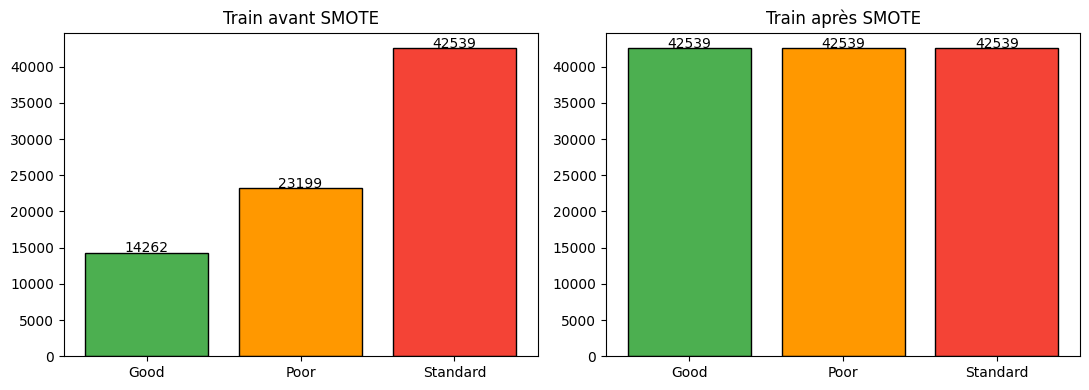

In [19]:
# visualisation avant / après SMOTE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#4caf50', '#ff9800', '#f44336']

for ax, y_data, title in [
    (axes[0], y_train, 'Train avant SMOTE'),
    (axes[1], y_train_res, 'Train après SMOTE')
]:
    v, c = np.unique(y_data, return_counts=True)
    labs = [le_target.classes_[i] for i in v]
    ax.bar(labs, c, color=colors[:len(v)], edgecolor='black')
    ax.set_title(title)
    for i, val in enumerate(c):
        ax.text(i, val + 100, str(val), ha='center')

plt.tight_layout()
plt.show()

---
## 4. Réduction de dimension (15 pts)

Deux approches complémentaires du Chapitre 4 du cours :

**Feature Selection** : méthode intégrée via la Forêt Aléatoire. On garde les 15 features les plus importantes.

**PCA** : Analyse en Composantes Principales. Réduit la dimension pour le SVM. Le cours montre d'utiliser StandardScaler avant la PCA.

In [20]:
# Feature Selection - méthode intégrée via Forêt Aléatoire (Chapitre 4)
# l'importance de chaque dimension = moyenne des impuretés des noeuds dans tous les arbres

rf_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    max_features=15
)
rf_selector.fit(X_train_res, y_train_res)

cols_sel = X_train_res.columns[rf_selector.get_support()].tolist()
print(f'{len(cols_sel)} dimensions sélectionnées : {cols_sel}')

8 dimensions sélectionnées : ['Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt']


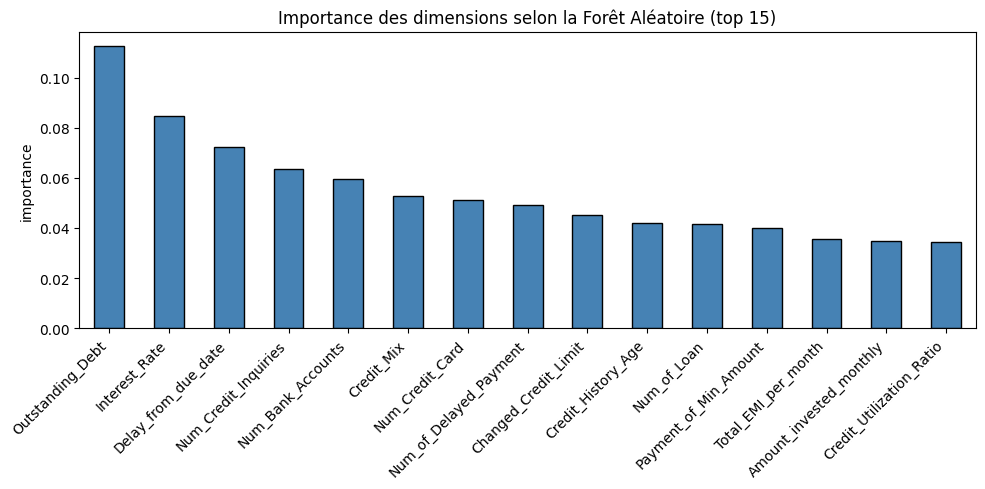

In [21]:
# graphique importance des dimensions
rf_temp = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_temp.fit(X_train_res, y_train_res)

importances = pd.Series(rf_temp.feature_importances_, index=X_train_res.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
top15.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Importance des dimensions selon la Forêt Aléatoire (top 15)')
plt.ylabel('importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# données avec seulement les features sélectionnées (pour RF et GB)
X_train_sel = X_train_res[cols_sel]
X_test_sel  = X_test[cols_sel]
print(f'shape après sélection : train={X_train_sel.shape} | test={X_test_sel.shape}')

shape après sélection : train=(127617, 8) | test=(20000, 8)


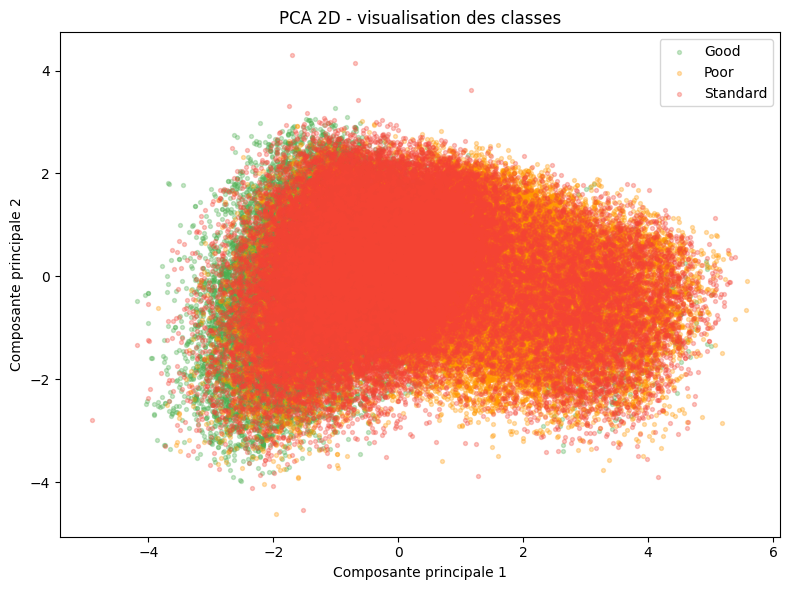

variance expliquée PC1+PC2 : 17.6%


In [23]:
# PCA - Analyse en Composantes Principales (Chapitre 4 du cours)
# le cours montre StandardScaler avant PCA (pas MinMax)
# important : on fit sur le train, on transform train ET test

sc_pca = StandardScaler()
X_train_std = sc_pca.fit_transform(X_train_res)
X_test_std  = sc_pca.transform(X_test)  # transform seulement, jamais fit sur le test

# visualisation 2D pour voir si les classes sont séparables
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_visu = pca_2d.fit_transform(X_train_std)

plt.figure(figsize=(8, 6))
colors_map = ['#4caf50', '#ff9800', '#f44336']
for i, cls in enumerate(le_target.classes_):
    mask = y_train_res == i
    plt.scatter(X_visu[mask, 0], X_visu[mask, 1],
                label=cls, alpha=0.3, s=8, color=colors_map[i])
plt.title('PCA 2D - visualisation des classes')
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.legend()
plt.tight_layout()
plt.show()
print(f'variance expliquée PC1+PC2 : {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')

composantes nécessaires pour 95% de variance expliquée : 20


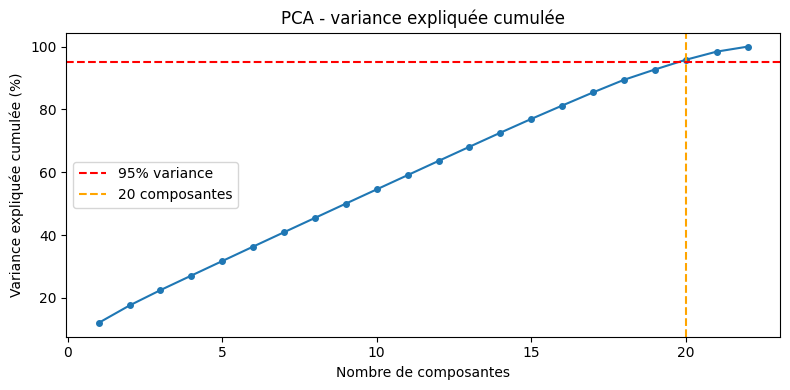

In [24]:
# courbe variance expliquée cumulée -> choisir le bon nombre de composantes
n_max = min(X_train_std.shape[1], 25)
pca_full = PCA(n_components=n_max, random_state=RANDOM_STATE).fit(X_train_std)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumsum >= 0.95) + 1
print(f'composantes nécessaires pour 95% de variance expliquée : {n_95}')

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumsum)+1), cumsum * 100, marker='o', markersize=4)
plt.axhline(95, color='red', linestyle='--', label='95% variance')
plt.axvline(n_95, color='orange', linestyle='--', label=f'{n_95} composantes')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée (%)')
plt.title('PCA - variance expliquée cumulée')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# application de la PCA avec n_95 composantes (pour le SVM)
pca = PCA(n_components=n_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca  = pca.transform(X_test_std)
print(f'après PCA : train={X_train_pca.shape} | test={X_test_pca.shape}')

après PCA : train=(127617, 20) | test=(20000, 20)


---
## 5. Modèles de classification (35 pts)

Trois modèles du Chapitre 3 :

**Forêt Aléatoire** : ensemble d'arbres décorrélés. Vote majoritaire.  
**LinearSVC** : SVM avec noyau linéaire. Beaucoup plus rapide que SVC RBF sur grands datasets (O(n) vs O(n²/n³)), résultats comparables après PCA.  
**Gradient Boosting** : arbres séquentiels, chaque arbre corrige les erreurs du précédent.

Stratégie de validation : **K-Fold stratifié k=5** (Chapitre 3 du cours).

In [26]:
def evaluer_modele(nom, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)

    # validation croisée k-fold stratifiée (Chapitre 3)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_f1 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1_weighted')

    print(f'\n=== {nom} ===')
    print(f'  accuracy    : {acc:.4f}')
    print(f'  f1 weighted : {f1:.4f}')
    print(f'  précision   : {prec:.4f} | rappel : {rec:.4f}')
    print(f'  CV k-fold (k=5) : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')

    return model, y_pred, {
        'nom': nom, 'accuracy': acc, 'f1': f1,
        'precision': prec, 'recall': rec,
        'cv_f1_mean': cv_f1.mean(), 'cv_f1_std': cv_f1.std()
    }

resultats = []
modeles_dict = {}
preds_dict   = {}

### 5.1 Forêt Aléatoire

Utilise les features sélectionnées (Feature Selection).  
Pas besoin de normalisation : les arbres font des seuils, pas des distances.

In [27]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

rf_model, rf_pred, rf_res = evaluer_modele(
    'Foret Aleatoire', rf,
    X_train_sel, y_train_res,
    X_test_sel, y_test
)
resultats.append(rf_res)
modeles_dict['Foret Aleatoire'] = rf_model
preds_dict['Foret Aleatoire']   = rf_pred


=== Foret Aleatoire ===
  accuracy    : 0.7659
  f1 weighted : 0.7663
  précision   : 0.7671 | rappel : 0.7659
  CV k-fold (k=5) : 0.8237 +/- 0.0026


### 5.2 SVM - LinearSVC

On utilise **LinearSVC** avec noyau linéaire à la place de SVC RBF.  
**Pourquoi :** SVC RBF sur 100 000 lignes peut prendre plusieurs heures (complexité O(n²) à O(n³)). LinearSVC est O(n), donc des dizaines de fois plus rapide pour un résultat comparable sur données après PCA.  
CalibratedClassifierCV enveloppe LinearSVC pour ajouter les probabilités en sortie (utile pour l'interface).

In [28]:
# LinearSVC + calibration pour avoir les probabilités
lsvc = LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=2000)
svm  = CalibratedClassifierCV(lsvc, cv=3)

svm_model, svm_pred, svm_res = evaluer_modele(
    'SVM (LinearSVC)', svm,
    X_train_pca, y_train_res,  # données après PCA + standardisation
    X_test_pca, y_test
)
resultats.append(svm_res)
modeles_dict['SVM (LinearSVC)'] = svm_model
preds_dict['SVM (LinearSVC)']   = svm_pred


=== SVM (LinearSVC) ===
  accuracy    : 0.5319
  f1 weighted : 0.5297
  précision   : 0.6220 | rappel : 0.5319
  CV k-fold (k=5) : 0.6004 +/- 0.0023


### 5.3 Gradient Boosting

Arbres construits séquentiellement. Chaque arbre apprend à corriger les erreurs du précédent.  
learning_rate=0.1 : vitesse d'apprentissage progressive, évite le surapprentissage.

In [29]:
gb = HistGradientBoostingClassifier(
    max_iter=100,        # equivalent de n_estimators
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_model, gb_pred, gb_res = evaluer_modele(
    'Gradient Boosting', gb,
    X_train_sel, y_train_res,
    X_test_sel, y_test
)
resultats.append(gb_res)
modeles_dict['Gradient Boosting'] = gb_model
preds_dict['Gradient Boosting']   = gb_pred


=== Gradient Boosting ===
  accuracy    : 0.6850
  f1 weighted : 0.6871
  précision   : 0.6959 | rappel : 0.6850
  CV k-fold (k=5) : 0.7575 +/- 0.0023


---
## 6. Évaluation des modèles (15 pts)

Métriques vues en cours (Chapitre 1) : accuracy, précision, rappel, F1-score, matrice de confusion.  
On privilégie le **F1 weighted** car les classes sont déséquilibrées.

In [30]:
# tableau comparatif
df_res = pd.DataFrame(resultats).set_index('nom').round(4)
print('Comparaison des 3 modèles :')
df_res

Comparaison des 3 modèles :


,accuracy,f1,precision,recall,cv_f1_mean,cv_f1_std
nom,,,,,,
Foret Aleatoire,0.7659,0.7663,0.7671,0.7659,0.8237,0.0026
SVM (LinearSVC),0.5319,0.5297,0.6220,0.5319,0.6004,0.0023
Gradient Boosting,0.6850,0.6871,0.6959,0.6850,0.7575,0.0023


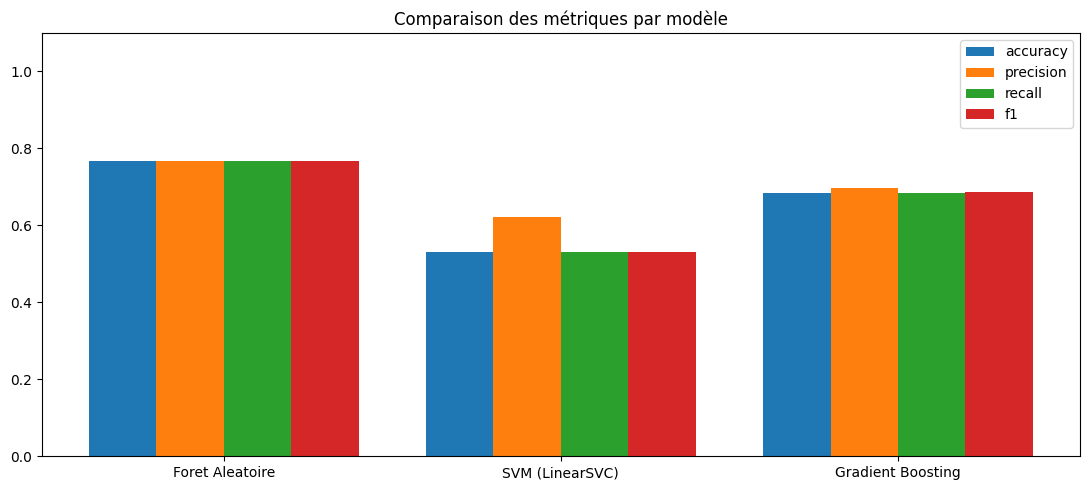

In [31]:
# graphique comparatif accuracy / précision / rappel / F1
metriques = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(df_res))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 5))
for i, m in enumerate(metriques):
    ax.bar(x + i*width, df_res[m], width, label=m)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(df_res.index)
ax.set_ylim(0, 1.1)
ax.set_title('Comparaison des métriques par modèle')
ax.legend()
plt.tight_layout()
plt.show()

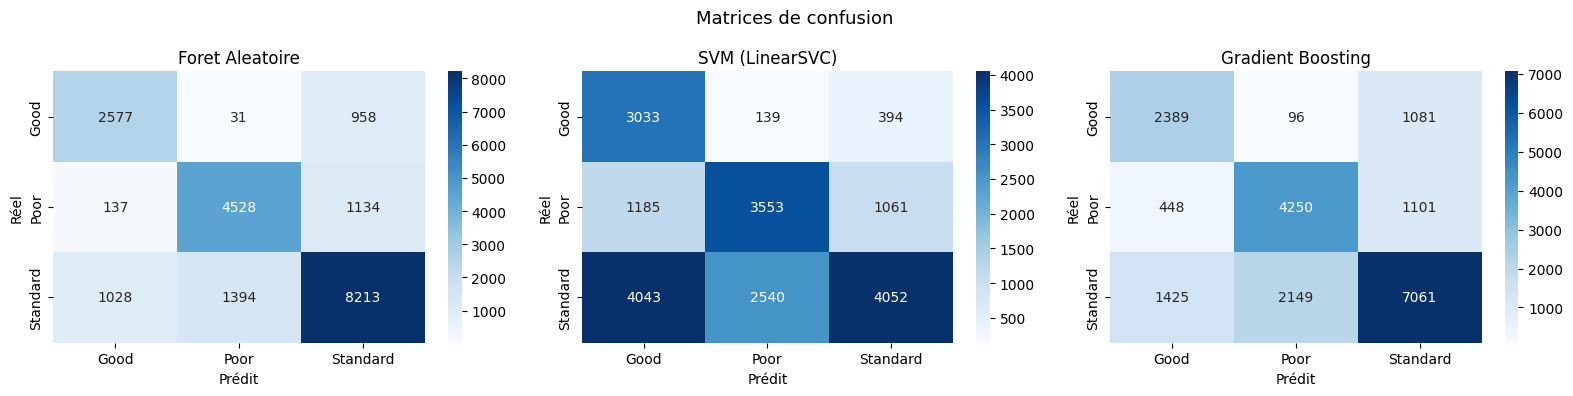

In [32]:
# matrices de confusion pour les 3 modèles
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (nom, y_pred) in zip(axes, preds_dict.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=le_target.classes_,
        yticklabels=le_target.classes_,
        cmap='Blues'
    )
    ax.set_title(nom)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion', fontsize=13)
plt.tight_layout()
plt.show()

In [33]:
# rapport détaillé du meilleur modèle
meilleur = df_res['f1'].idxmax()
print(f'Meilleur modèle (F1 weighted) : {meilleur}\n')
print(classification_report(
    y_test, preds_dict[meilleur],
    target_names=le_target.classes_
))

Meilleur modèle (F1 weighted) : Foret Aleatoire

              precision    recall  f1-score   support

        Good       0.69      0.72      0.71      3566
        Poor       0.76      0.78      0.77      5799
    Standard       0.80      0.77      0.78     10635

    accuracy                           0.77     20000
   macro avg       0.75      0.76      0.75     20000
weighted avg       0.77      0.77      0.77     20000



---
## 7. Sauvegarde des modèles et transformateurs

On sauvegarde tout ce dont l'interface Streamlit aura besoin.  
Les transformateurs (scaler, imputer, encodeurs, PCA) sont indispensables pour appliquer le même pipeline sur de nouvelles données.

In [34]:
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

# transformateurs
joblib.dump(scaler,              'models/scaler.pkl')
joblib.dump(imputer,             'models/imputer.pkl')
joblib.dump(encoders,            'models/encoders_cat.pkl')
joblib.dump(le_target,           'models/le_target.pkl')
joblib.dump(sc_pca,              'models/sc_pca.pkl')
joblib.dump(pca,                 'models/pca.pkl')
joblib.dump(cols_sel,            'models/cols_sel.pkl')
joblib.dump(list(X.columns),     'models/feature_cols.pkl')

# modèles
joblib.dump(rf_model,            'models/random_forest.pkl')
joblib.dump(svm_model,           'models/svm.pkl')
joblib.dump(gb_model,            'models/gradient_boosting.pkl')

# résultats
df_res.to_csv('data/resultats_modeles.csv')

print('tout sauvegardé dans models/ et data/')

tout sauvegardé dans models/ et data/


---
## Bilan

- [x] Préparation des données : nettoyage regex, imputation médiane, normalisation min-max, SMOTE
- [x] Réduction de dimension : Feature Selection (RF intégrée) + PCA avec StandardScaler
- [x] 3 modèles : Forêt Aléatoire, SVM (LinearSVC), Gradient Boosting
- [x] Évaluation : accuracy, F1 weighted, précision, rappel, matrices de confusion, K-Fold k=5
- [ ] Interface Streamlit -> `app/app.py`